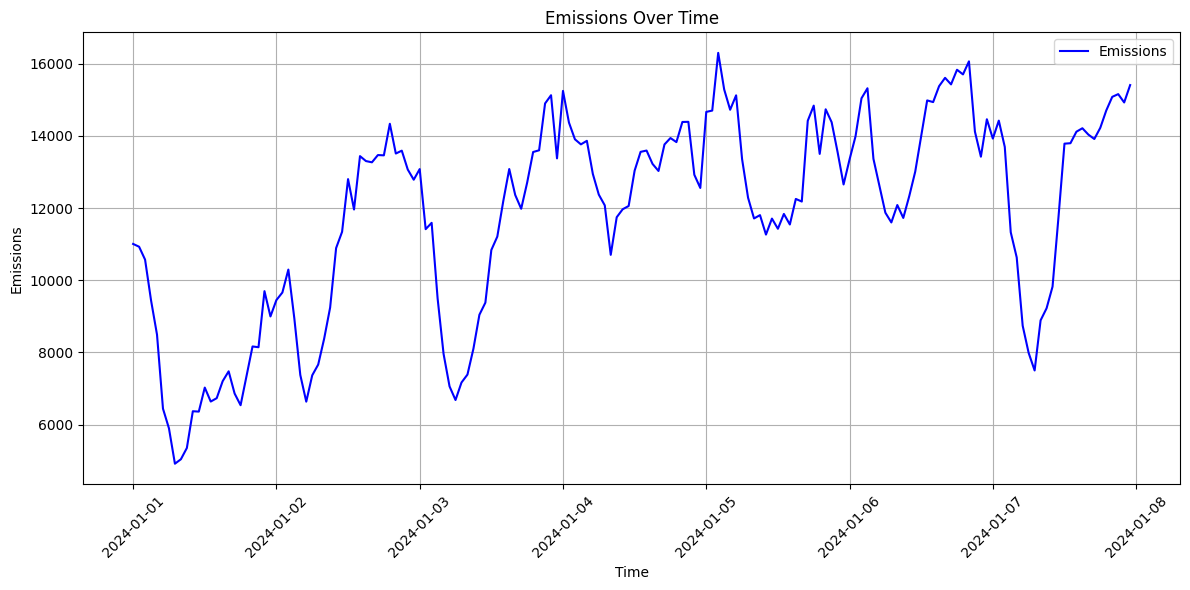

In [3]:
# Cell 1: Import required libraries
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Cell 2: Read the JSON file
# Replace 'checkpoint_hour_168.json' with the path to your JSON file
with open('/home/chad/Desktop/multi-tier-llm-routing-v2/results/2024_hourly_parallel/checkpoint_hour_168.json', 'r') as file:
    data = json.load(file)

# Cell 3: Extract emissions and timestamps
results = data['results']
emissions = [entry['emissions'] for entry in results]
timestamps = [datetime.strptime(entry['timestamp'], '%Y-%m-%dT%H:%M:%S') for entry in results]

# Cell 4: Plot the graph
plt.figure(figsize=(12, 6))
plt.plot(timestamps, emissions, linestyle='-', color='b', label='Emissions')
plt.xlabel('Time')
plt.ylabel('Emissions')
plt.title('Emissions Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cumulative Emissions Over Time for 1 year

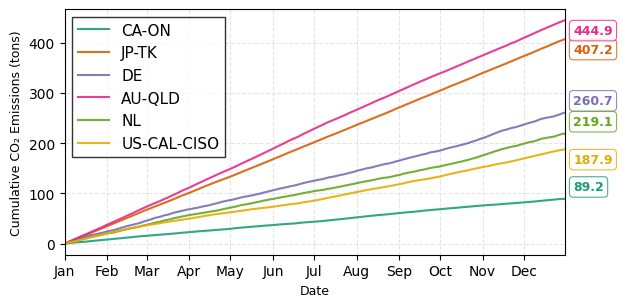

Figure saved as 'cumulative_emissions_regions_2024.png' and '.pdf'

=== Annual CO₂ Emissions Summary (metric tons) ===
  CA-ON: 89,165.9 tons CO₂ over 8760 hours
  JP-TK: 407,160.0 tons CO₂ over 8760 hours
  DE: 260,694.0 tons CO₂ over 8760 hours
  AU-QLD: 444,926.3 tons CO₂ over 8760 hours
  NL: 219,074.3 tons CO₂ over 8760 hours
  US-CAL-CISO: 187,856.9 tons CO₂ over 8760 hours


In [1]:
# Cell 1: Import libraries
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os
import pandas as pd

# Set global font to Arial (MDPI requirement)
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'grid.color': '#cccccc',
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight'
})

# Cell 2: === USER INPUT: File paths and region names ===
file_paths = [
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/JP-TK_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/DE_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/AU-QLD_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/NL_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/US-CAL-CISO_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json'
]

region_names = ['CA-ON', 'JP-TK', 'DE', 'AU-QLD', 'NL', 'US-CAL-CISO']

# Validate
if len(region_names) != len(file_paths):
    raise ValueError("Number of region names must match number of file paths!")

# Colorblind-safe palette (from ColorBrewer)
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']


# Cell 3: Create MDPI-compliant figure (16 cm x 8 cm)
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))  # cm → inches

all_timestamps = []

for i, (fp, region) in enumerate(zip(file_paths, region_names)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue
    
    with open(fp, 'r') as f:
        data = json.load(f)
    
    results = data.get('results', [])
    if not results:
        print(f"Warning: No results in {fp}")
        continue

    # Extract and convert
    try:
        timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
        emissions_g = [e['emissions'] for e in results]
    except KeyError as e:
        print(f"Warning: Missing key {e} in {fp}")
        continue

    # Convert to **metric tons**
    emissions_tons = np.array(emissions_g) / 1_000_000.0
    cumulative_tons = np.cumsum(emissions_tons)

    # Plot
    ax.plot(timestamps, cumulative_tons,
            label=f'{region}',
            color=colors[i], alpha=0.9)

    # Annotate final value in **tons**
    total_tons = cumulative_tons[-1]
    last_time = timestamps[-1]
    ax.annotate(f'{total_tons:,.1f}',
                xy=(last_time, total_tons),
                xytext=(6, 6 if i % 2 == 0 else -10),
                textcoords='offset points',
                fontsize=9, color=colors[i], fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor=colors[i], linewidth=0.8))

    all_timestamps.extend(timestamps)

# Cell 4: Final formatting (MDPI style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative CO₂ Emissions (tons)')
#ax.set_title('Yearly Cumulative CO₂ Emissions by Region (2024, QoR = 0.50)')

# Monthly ticks
if all_timestamps:
    min_date = min(all_timestamps)
    max_date = max(all_timestamps)
    ax.set_xlim(min_date, max_date)
    
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(month_fmt)

# Legend outside if needed
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

# Tight layout already enabled via rcParams
plt.show()

# Cell 5: Export for MDPI (high-res PNG)
fig.savefig('cumulative_emissions_regions_2024.png', dpi=300)
fig.savefig('cumulative_emissions_regions_2024.pdf')  # Vector version
print("Figure saved as 'cumulative_emissions_regions_2024.png' and '.pdf'")

# Cell 6: Print summary in tons
print("\n=== Annual CO₂ Emissions Summary (metric tons) ===")
for fp, name in zip(file_paths, region_names):
    if os.path.exists(fp):
        with open(fp, 'r') as f:
            data = json.load(f)
        total_kg = np.cumsum([e['emissions'] for e in data['results']])[-1]
        total_tons = total_kg / 1000.0
        hours = len(data['results'])
        print(f"  {name}: {total_tons:,.1f} tons CO₂ over {hours} hours")
    else:
        print(f"  {name}: FILE NOT FOUND")

#### samea  as above but for IEEE

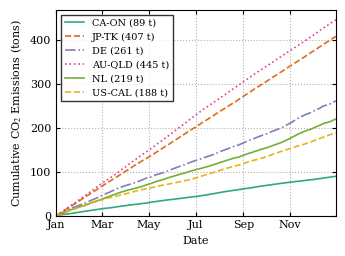

Saved ieee_cumulative_emissions.pdf and .png


In [6]:
# Cell 1: Import libraries
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os

# --- IEEE Styling Setup ---
# IEEE standard column width is approx 3.5 inches (8.89 cm).
# Double column is approx 7.16 inches.
# We use Times New Roman (serif) and specific font sizes.

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,              # IEEE standard caption/text size is often 8pt
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,        # Slightly smaller for legend
    'figure.autolayout': True,
    'lines.linewidth': 1.2,      # Thinner lines for precision
    'axes.grid': True,
    'grid.linestyle': ':',       # Dotted grid is less intrusive
    'grid.alpha': 0.6,
    'grid.color': 'gray',
    'savefig.dpi': 600,          # High DPI for publication
    'savefig.format': 'pdf',     # PDF is preferred for vector graphics
    'savefig.bbox': 'tight',
    'text.usetex': False,        # Set True if you have LaTeX installed locally
    'mathtext.fontset': 'stix'   # better looking math symbols in non-latex mode
})

# Cell 2: === USER INPUT: File paths and region names ===
file_paths = [
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/JP-TK_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/DE_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/AU-QLD_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/NL_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/US-CAL-CISO_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json'
]

region_names = ['CA-ON', 'JP-TK', 'DE', 'AU-QLD', 'NL', 'US-CAL']

# Validate
if len(region_names) != len(file_paths):
    raise ValueError("Number of region names must match number of file paths!")

# Define colors and linestyles to differentiation in B&W
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']
linestyles = ['-', '--', '-.', ':', '-', '--'] # Cycle through styles

# Cell 3: Create IEEE-compliant figure
# Width: 3.5 inches (single column). Height: 2.5 inches (golden ratio-ish)
fig, ax = plt.subplots(figsize=(3.5, 2.6)) 

all_timestamps = []

for i, (fp, region) in enumerate(zip(file_paths, region_names)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue
    
    with open(fp, 'r') as f:
        data = json.load(f)
    
    results = data.get('results', [])
    if not results:
        continue

    # Extract and convert
    timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
    emissions_g = [e['emissions'] for e in results]

    # Convert to metric tons
    emissions_tons = np.array(emissions_g) / 1_000_000.0
    cumulative_tons = np.cumsum(emissions_tons)
    final_val = cumulative_tons[-1]

    # Plot
    # We include the final value in the legend label for cleanliness
    # Note: Use $$ for math formatting of units if desired
    label_text = f'{region} ({final_val:,.0f} t)'
    
    ax.plot(timestamps, cumulative_tons,
            label=label_text,
            color=colors[i % len(colors)], 
            linestyle=linestyles[i % len(linestyles)],
            linewidth=1.2,
            alpha=0.9)
    
    all_timestamps.extend(timestamps)

# Cell 4: Formatting
# Use LaTeX-like formatting for chemical formulas
ax.set_xlabel('Date')
ax.set_ylabel(r'Cumulative CO$_2$ Emissions (tons)')

# Monthly ticks
if all_timestamps:
    min_date = min(all_timestamps)
    max_date = max(all_timestamps)
    ax.set_xlim(min_date, max_date)
    
    # Tick locator - specific for smaller IEEE plots
    # Too many ticks makes the axis unreadable
    months = mdates.MonthLocator(interval=2) # Every 2 months
    month_fmt = mdates.DateFormatter('%b')
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(month_fmt)

# Legend settings suitable for academic paper
# 'loc=best' usually finds a spot, but 'upper left' is standard for cumulative plots
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black', ncol=1)

# Ensure 0 is at bottom
ax.set_ylim(bottom=0)

plt.show()

# Cell 5: Export
# IEEE requires high-res figures. PDF/EPS is best.
fig.savefig('ieee_cumulative_emissions.pdf', format='pdf', dpi=600)
fig.savefig('ieee_cumulative_emissions.png', format='png', dpi=600)
print("Saved ieee_cumulative_emissions.pdf and .png")

## multi-region vs qor

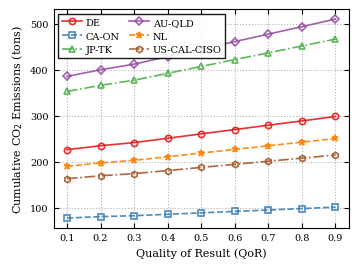

Saved: ieee_emissions_qor.pdf, ieee_emissions_qor.png


In [2]:
# Cell 1: Imports + IEEE Styling
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import numpy as np
import os
from cycler import cycler

# ---- IEEE Styling rcParams ------------------------------------
# Target: Single column width = ~3.5 inches
# Font: Times New Roman (matches standard IEEE body text)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
    'font.size': 8,              # Standard fit for 3.5inch figures
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.figsize': (3.5, 2.6), # Width: 3.5in (single column), Height: 2.6in (aspect ratio)
    'lines.linewidth': 1.2,
    'lines.markersize': 4.5,     # Slightly smaller for compact plots
    'axes.grid': True,
    'grid.linestyle': ':',       # Dotted grid is less intrusive
    'grid.alpha': 0.6,
    'grid.color': 'gray',
    'savefig.dpi': 600,          # Higher DPI for publication
    'savefig.bbox': 'tight',
    'xtick.direction': 'in',     # Ticks inside the box
    'ytick.direction': 'in',
    'xtick.top': True,           # Ticks on all sides
    'ytick.right': True,
})

# Cell 2: === USER INPUT: Regions and QoR values ===
# Note: Regions sorted or ordered specifically if desired
regions = ['DE', 'CA-ON', 'JP-TK', 'AU-QLD', 'NL', 'US-CAL-CISO']
qor_values = ['0.10', '0.20', '0.30', '0.40', '0.50', '0.60', '0.70', '0.80', '0.90']

# Base path
base_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results'

# Cell 3: Extract data
data_by_region = {}

for region in regions:
    data_by_region[region] = {}
    for qor in qor_values:
        fp = f"{base_path}/{region}_2024_qor_sweep/qor_{qor}/checkpoint_hour_8760.json"
        
        # Basic error handling to skip missing files without crashing
        if not os.path.exists(fp):
            continue

        try:
            with open(fp, 'r') as f:
                js = json.load(f)

            results = js.get('results', [])
            if not results:
                continue

            # Sum emissions (grams -> tons)
            emissions_g = [e.get('emissions', 0) for e in results]
            total_tons = np.sum(emissions_g) / 1_000_000.0
            data_by_region[region][float(qor)] = total_tons
            
        except Exception as e:
            print(f"Error reading {fp}: {e}")
            continue

# Filter out empty regions
data_by_region = {r: d for r, d in data_by_region.items() if d}

if not data_by_region:
    # Create Dummy Data for visualization if file path doesn't exist
    print("Warning: No data found. Generating DUMMY data for preview...")
    qor_float = [float(q) for q in qor_values]
    np.random.seed(42)
    for r in regions:
        # Create a curve that generally decreases or changes with QoR
        base = np.random.uniform(100, 1000)
        data_by_region[r] = {q: base * (1 - (q*0.5)) + np.random.normal(0, 10) for q in qor_float}

# Cell 4: Plotting Logic
fig, ax = plt.subplots()

# Define markers and linestyles for B&W distinctiveness
# Order: Circle, Square, Triangle Up, Diamond, Star, Hexagon
marker_cycle = ['o', 's', '^', 'D', '*', 'h'] 
# Order: Solid, Dashed, Dash-Dot
ls_cycle = ['-', '--', '-.', '-', '--', '-.']
# High contrast colors (ColorBrewer Set1 or similar)
color_cycle = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

qor_sorted = sorted({q for d in data_by_region.values() for q in d.keys()})

# Loop through regions
for i, region in enumerate(data_by_region.keys()):
    qors = sorted(data_by_region[region].keys())
    tons = [data_by_region[region][q] for q in qors]
    
    # Cycle properties
    m = marker_cycle[i % len(marker_cycle)]
    ls = ls_cycle[i % len(ls_cycle)]
    c = color_cycle[i % len(color_cycle)]
    
    ax.plot(qors, tons,
            label=region,
            color=c,
            marker=m,
            linestyle=ls,
            markerfacecolor='none', # Open markers are cleaner for publication
            markeredgewidth=1.2,
            alpha=0.9)

# Cell 5: Formatting
ax.set_xlabel('Quality of Result (QoR)')
# Use LaTeX-like formatting for subscripts if allowed, or simple text
ax.set_ylabel(r'Cumulative CO$_2$ Emissions (tons)')

# Set X-axis
ax.set_xticks(qor_sorted)
# If too many ticks, slice the list: e.g., qor_sorted[::2]
ax.set_xticklabels([f'{q:.1f}' for q in qor_sorted])

# Set Y-axis thousands separator
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Legend Configuration for IEEE
# Placed inside the plot (best), usually 1 or 2 columns
ax.legend(
    loc='best',          # Automatically finds the empty spot
    ncol=2,              # Two columns makes it more compact horizontally
    frameon=True,        
    edgecolor='black',   # Sharp border
    fancybox=False,      # Square corners
    framealpha=0.9,      # Opaque background so lines don't show through
    columnspacing=1.0,
    handletextpad=0.4
)

plt.tight_layout(pad=0.5) # Minimize white space around the plot
plt.show()

# Cell 6: Export
# PDF is best for LaTeX/Overleaf integration
fig.savefig('ieee_emissions_qor.pdf', format='pdf') 
fig.savefig('ieee_emissions_qor.png', dpi=600)

print("Saved: ieee_emissions_qor.pdf, ieee_emissions_qor.png")

# Energy

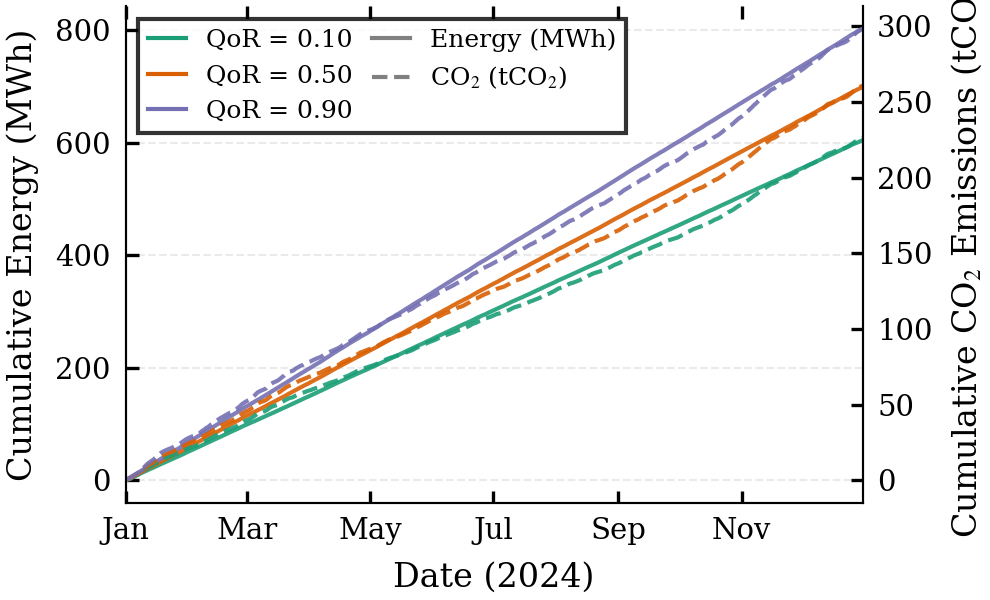

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Figure saved:
  cumulative_energy_emissions_DE_dual_axis.png
  cumulative_energy_emissions_DE_dual_axis.pdf
  cumulative_energy_emissions_DE_dual_axis.eps

  DE: Annual Totals by QoR Level
  QoR          Energy (MWh)    CO₂ (tCO₂)     
  ------------------------------------------
  0.10         604             226            
  0.50         699             261            
  0.90         803             298            


In [12]:
# =========================================================
#  IEEE-style: Dual Y-Axis - Cumulative Energy (MWh) & CO₂ (tons)
# =========================================================

import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os

# ---- IEEE style rcParams ------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.autolayout': True,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'grid.color': '#cccccc',
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'text.usetex': False,  # Set True if LaTeX is available
})

# === USER INPUT ===
region = 'DE'
qor_values = ['0.10', '0.50', '0.90']
base_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results'

file_paths = [
    f"{base_path}/{region}_2024_qor_sweep/qor_{qor}/checkpoint_hour_8760.json"
    for qor in qor_values
]

qor_labels = [f'QoR = {float(q):.2f}' for q in qor_values]

# IEEE-friendly colorblind-safe palette
colors = ['#1b9e77', '#d95f02', '#7570b3']  # Teal, Orange, Purple

# === Create figure (IEEE single column: 3.5 in, double column: 7.16 in) ===
fig, ax1 = plt.subplots(figsize=(3.5, 2.2))  # Single column width

# Create secondary y-axis
ax2 = ax1.twinx()

all_timestamps = []
endpoints_energy = []
endpoints_emissions = []

for i, (fp, label) in enumerate(zip(file_paths, qor_labels)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue

    with open(fp, 'r') as f:
        data = json.load(f)

    results = data.get('results', [])
    if not results:
        print(f"Warning: No results in {fp}")
        continue

    # ---- Parse data ------------------------------------------------
    try:
        timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
        
        # Energy (kWh → MWh)
        if 'energy_kwh' in results[0]:
            energy_kwh = [e['energy_kwh'] for e in results]
        else:
            energy_kwh = [e['energy'] for e in results]
        energy_mwh = np.array(energy_kwh) / 1000.0
        cumulative_mwh = np.cumsum(energy_mwh)
        
        # Emissions (g → tons)
        emissions_g = [e['emissions'] for e in results]
        emissions_tons = np.array(emissions_g) / 1_000_000
        cumulative_tons = np.cumsum(emissions_tons)
        
    except KeyError as e:
        print(f"Warning: Missing key {e} in {fp}")
        continue

    color = colors[i % len(colors)]
    
    # Plot energy on left axis (solid line)
    line1, = ax1.plot(timestamps, cumulative_mwh,
                      color=color, linestyle='-', linewidth=1.0,
                      label=label, alpha=0.9)
    
    # Plot emissions on right axis (dashed line, same color)
    line2, = ax2.plot(timestamps, cumulative_tons,
                      color=color, linestyle='--', linewidth=1.0,
                      alpha=0.9)

    all_timestamps.extend(timestamps)
    
    # Store endpoints for annotation
    endpoints_energy.append({
        "y": cumulative_mwh[-1],
        "color": color,
        "label": label
    })
    endpoints_emissions.append({
        "y": cumulative_tons[-1],
        "color": color
    })

# === Formatting ===

# X-axis
if all_timestamps:
    ax1.set_xlim(min(all_timestamps), max(all_timestamps))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax1.set_xlabel('Date (2024)')

# Left Y-axis (Energy)
ax1.set_ylabel('Cumulative Energy (MWh)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Right Y-axis (Emissions)
ax2.set_ylabel('Cumulative CO$_2$ Emissions (tCO$_2$)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Grid (only on primary axis)
ax1.yaxis.grid(True)
ax1.xaxis.grid(False)
ax2.grid(False)

# Spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# === Legend with line style indicators ===
from matplotlib.lines import Line2D

# Custom legend entries
legend_elements = []
for i, label in enumerate(qor_labels):
    if i < len(colors):
        legend_elements.append(Line2D([0], [0], color=colors[i], linewidth=1.0, label=label))

# Add line style indicators
legend_elements.append(Line2D([0], [0], color='gray', linestyle='-', linewidth=1.0, label='Energy (MWh)'))
legend_elements.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=1.0, label='CO$_2$ (tCO$_2$)'))

ax1.legend(handles=legend_elements, loc='upper left', frameon=True, 
           fancybox=False, edgecolor='black', fontsize=6, 
           ncol=2, columnspacing=0.8, handlelength=1.5)

plt.tight_layout()
plt.show()

# === Export ===
fig.savefig(f'cumulative_energy_emissions_{region}_dual_axis.png', dpi=600)
fig.savefig(f'cumulative_energy_emissions_{region}_dual_axis.pdf')
fig.savefig(f'cumulative_energy_emissions_{region}_dual_axis.eps')  # IEEE often prefers EPS
print(f"\nFigure saved:")
print(f"  cumulative_energy_emissions_{region}_dual_axis.png")
print(f"  cumulative_energy_emissions_{region}_dual_axis.pdf")
print(f"  cumulative_energy_emissions_{region}_dual_axis.eps")

# === Summary Table ===
print(f"\n{'='*60}")
print(f"  {region}: Annual Totals by QoR Level")
print(f"{'='*60}")
print(f"  {'QoR':<12} {'Energy (MWh)':<15} {'CO₂ (tCO₂)':<15}")
print(f"  {'-'*42}")
for i, (qor, ep_e, ep_c) in enumerate(zip(qor_values, endpoints_energy, endpoints_emissions)):
    print(f"  {float(qor):<12.2f} {ep_e['y']:<15,.0f} {ep_c['y']:<15,.0f}")
print(f"{'='*60}")